In [1]:
# ============================================================
# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style='whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Install dependencies as needed:
%%capture
!pip install kagglehub[pandas-datasets]

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Correct file path
file_path = "Mall_Customers.csv"

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shwetabh123/mall-customers",
    file_path,
    pandas_kwargs={
        "encoding": "latin-1"
    }
)

print("Dataset loaded successfully!")

Using Colab cache for faster access to the 'mall-customers' dataset.
Dataset loaded successfully!


In [4]:
# ============================================================
# 3. DISPLAY FIRST 5 ROWS
# ============================================================

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# ============================================================
# 4. DATASET OVERVIEW
# ============================================================

print("Shape of dataset:", df.shape)

Shape of dataset: (200, 5)


In [6]:
# ============================================================
# 5. COLUMN NAMES
# ============================================================

df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
# ============================================================
# 6. DATA TYPES
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
# ============================================================
# 7. CHECK MISSING VALUES
# ============================================================

df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
# ============================================================
# 8. STATISTICAL SUMMARY
# ============================================================

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# ============================================================
# 9. RENAME COLUMNS FOR EASIER USAGE
# ============================================================

df.rename(columns={
    'Genre' : 'Gender',
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendingScore'
}, inplace=True)

df.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
# ============================================================
# 10. CHECK DUPLICATE VALUES
# ============================================================

df.duplicated().sum()

np.int64(0)

In [12]:
# ============================================================
# 11. ENCODE GENDER COLUMN
# ============================================================

encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

# Male = 1
# Female = 0

df.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


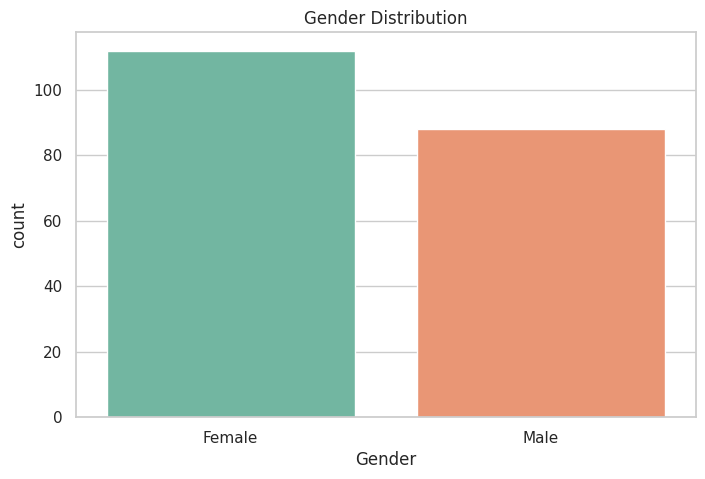

In [13]:
# ============================================================
# 12. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Gender',
    data=df,
    palette='Set2'
)

plt.title("Gender Distribution")
plt.xticks([0,1], ['Female', 'Male'])

plt.show()

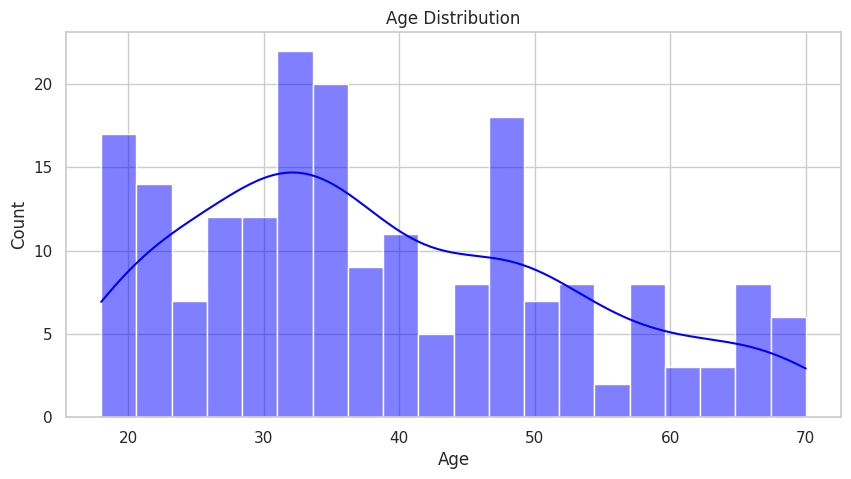

In [14]:
# ============================================================
# 13. AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True,
    color='blue'
)

plt.title("Age Distribution")

plt.show()

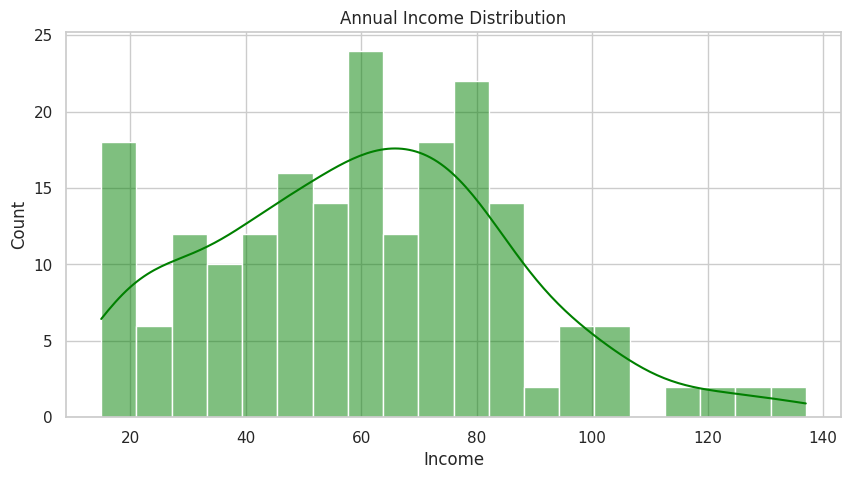

In [15]:
# ============================================================
# 14. ANNUAL INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['Income'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("Annual Income Distribution")

plt.show()

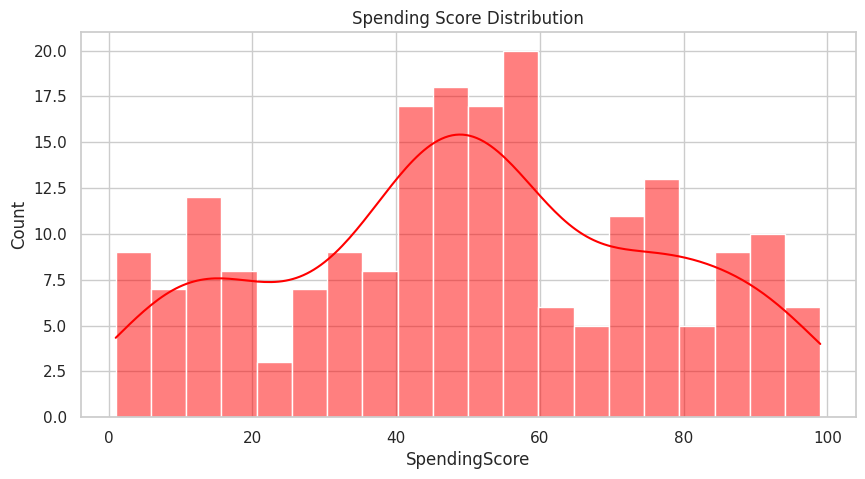

In [16]:
# ============================================================
# 15. SPENDING SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['SpendingScore'],
    bins=20,
    kde=True,
    color='red'
)

plt.title("Spending Score Distribution")

plt.show()

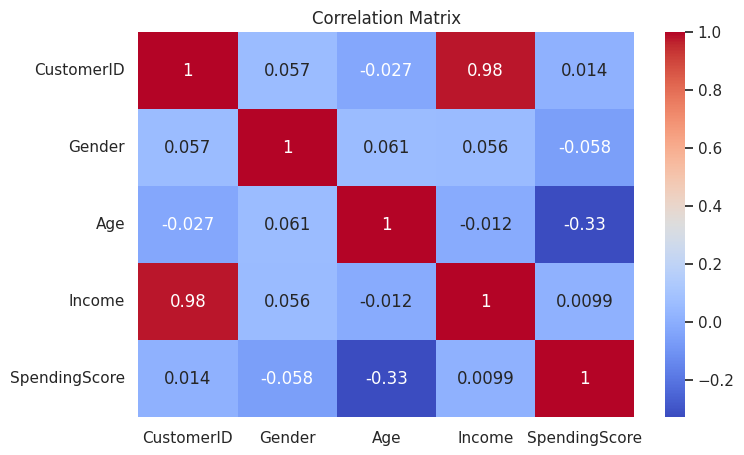

In [17]:
# ============================================================
# 16. CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

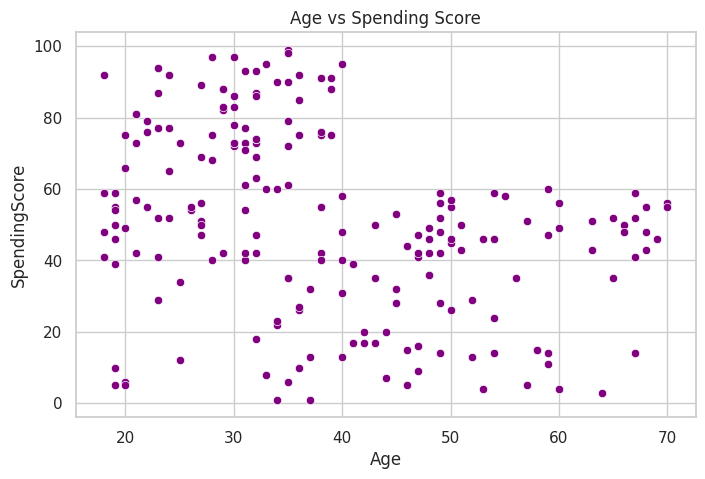

In [18]:
# ============================================================
# 17. SCATTER PLOT - AGE VS SPENDING SCORE
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='SpendingScore',
    data=df,
    color='purple'
)

plt.title("Age vs Spending Score")

plt.show()

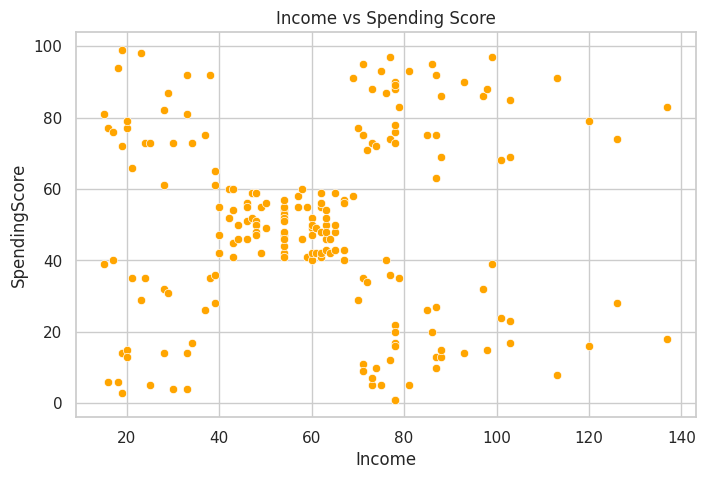

In [19]:
# ============================================================
# 18. SCATTER PLOT - INCOME VS SPENDING SCORE
# ============================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Income',
    y='SpendingScore',
    data=df,
    color='orange'
)

plt.title("Income vs Spending Score")

plt.show()

In [20]:
# ============================================================
# 19. SELECT FEATURES FOR CLUSTERING
# ============================================================

X = df[['Income', 'SpendingScore']]

X.head()

,Income,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [21]:
# ============================================================
# 20. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


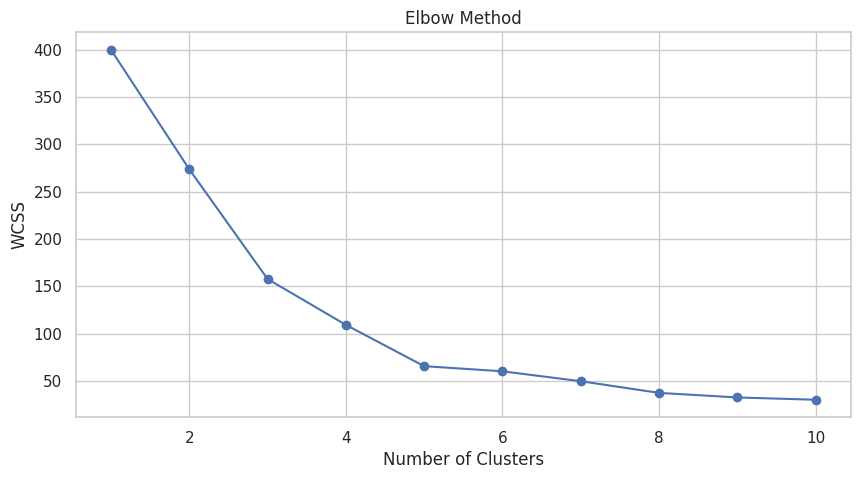

In [22]:
# ============================================================
# 21. FIND OPTIMAL NUMBER OF CLUSTERS
# USING ELBOW METHOD
# ============================================================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(10,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [23]:
# ============================================================
# 22. SILHOUETTE SCORE ANALYSIS
# ============================================================

for n_clusters in range(2, 11):

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(
        X_scaled,
        cluster_labels
    )

    print(
        "For n_clusters =",
        n_clusters,
        "The silhouette score is:",
        round(silhouette_avg, 3)
    )

For n_clusters = 2 The silhouette score is: 0.397
For n_clusters = 3 The silhouette score is: 0.467
For n_clusters = 4 The silhouette score is: 0.494
For n_clusters = 5 The silhouette score is: 0.555
For n_clusters = 6 The silhouette score is: 0.514
For n_clusters = 7 The silhouette score is: 0.502
For n_clusters = 8 The silhouette score is: 0.455
For n_clusters = 9 The silhouette score is: 0.457
For n_clusters = 10 The silhouette score is: 0.445


In [24]:
# ============================================================
# 23. TRAIN FINAL K-MEANS MODEL
# ============================================================

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X_scaled)

print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [25]:
# ============================================================
# 24. ADD CLUSTER LABELS TO DATASET
# ============================================================

df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Income,SpendingScore,Cluster
0,1,1,19,15,39,4
1,2,1,21,15,81,2
2,3,0,20,16,6,4
3,4,0,23,16,77,2
4,5,0,31,17,40,4


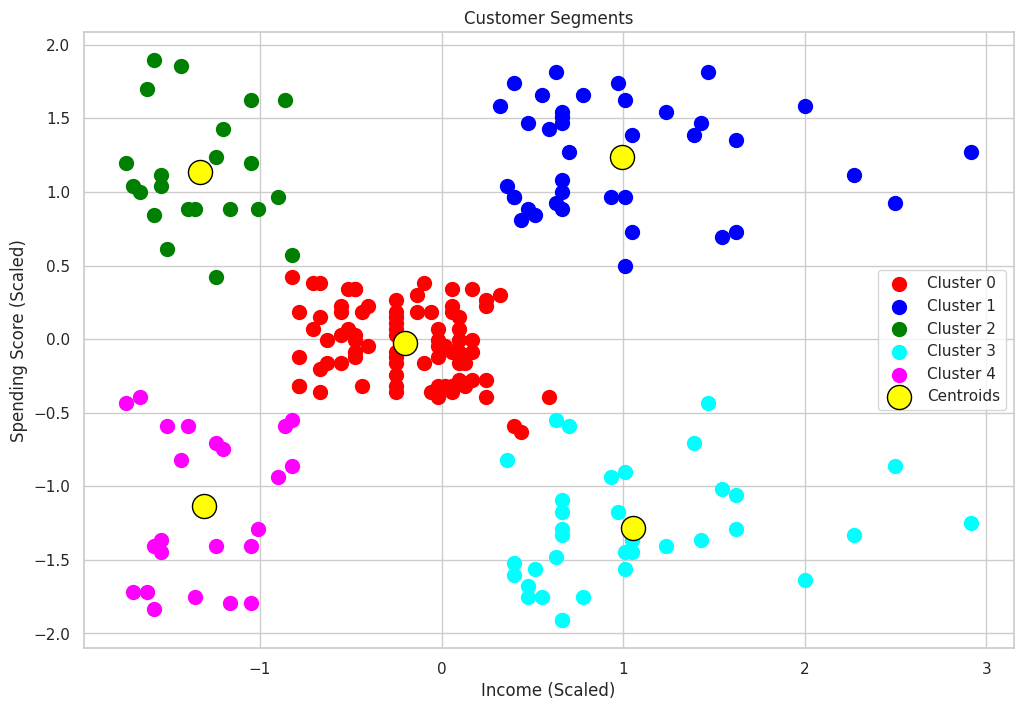

In [26]:
# ============================================================
# 25. VISUALIZE CUSTOMER SEGMENTS
# ============================================================

plt.figure(figsize=(12,8))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):

    plt.scatter(
        X_scaled[y_kmeans == i, 0],
        X_scaled[y_kmeans == i, 1],
        s=100,
        c=colors[i],
        label=f'Cluster {i}'
    )

# Plot cluster centroids

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='yellow',
    label='Centroids',
    edgecolors='black'
)

plt.title("Customer Segments")
plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()

plt.show()

In [27]:
# ============================================================
# 26. CLUSTER-WISE ANALYSIS
# ============================================================

cluster_summary = df.groupby('Cluster').mean()

cluster_summary

,CustomerID,Gender,Age,Income,SpendingScore
Cluster,,,,,
0,86.320988,0.407407,42.716049,55.296296,49.518519
1,162.000000,0.461538,32.692308,86.538462,82.128205
2,23.090909,0.409091,25.272727,25.727273,79.363636
3,164.371429,0.542857,41.114286,88.200000,17.114286
4,23.000000,0.391304,45.217391,26.304348,20.913043


In [28]:
# ============================================================
# 27. NUMBER OF CUSTOMERS IN EACH CLUSTER
# ============================================================

df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


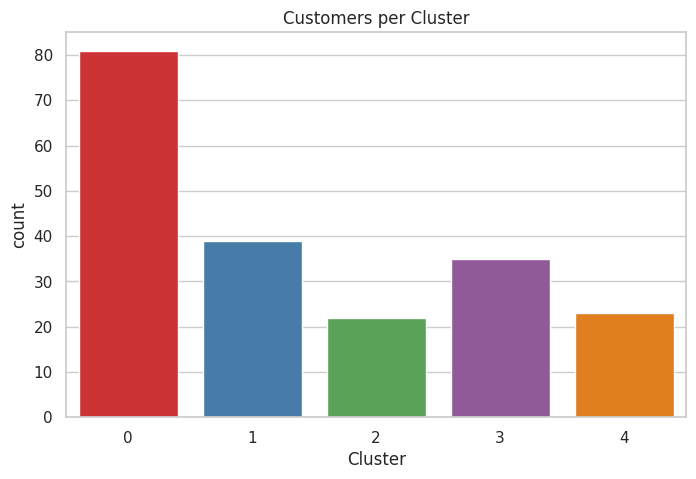

In [29]:
# ============================================================
# 28. VISUALIZE CLUSTER COUNTS
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df,
    palette='Set1'
)

plt.title("Customers per Cluster")

plt.show()

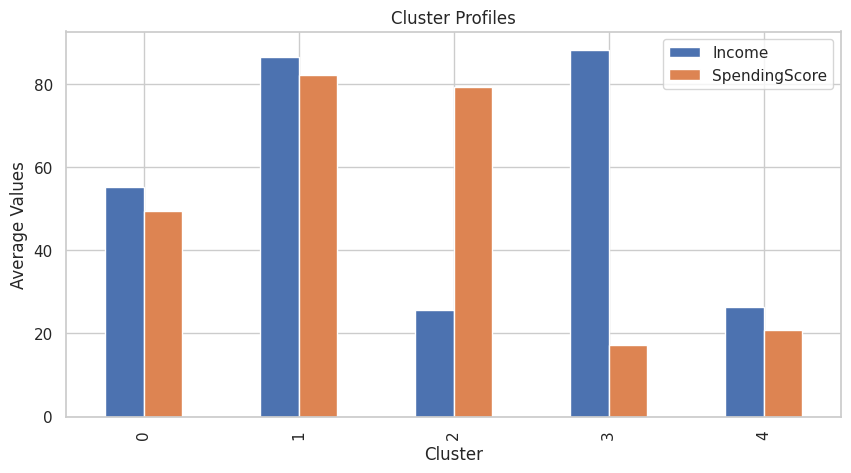

In [30]:
# ============================================================
# 29. CLUSTER PROFILE VISUALIZATION
# ============================================================

cluster_summary[['Income', 'SpendingScore']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Cluster Profiles")
plt.ylabel("Average Values")

plt.show()

In [31]:
# ============================================================
# 30. INTERPRET CLUSTERS
# ============================================================

for cluster in sorted(df['Cluster'].unique()):

    print("\n===================================")
    print(f"CLUSTER {cluster}")
    print("===================================")

    cluster_data = df[df['Cluster'] == cluster]

    print("Average Age:",
          round(cluster_data['Age'].mean(), 2))

    print("Average Income:",
          round(cluster_data['Income'].mean(), 2))

    print("Average Spending Score:",
          round(cluster_data['SpendingScore'].mean(), 2))

    print("Total Customers:",
          cluster_data.shape[0])


CLUSTER 0
Average Age: 42.72
Average Income: 55.3
Average Spending Score: 49.52
Total Customers: 81

CLUSTER 1
Average Age: 32.69
Average Income: 86.54
Average Spending Score: 82.13
Total Customers: 39

CLUSTER 2
Average Age: 25.27
Average Income: 25.73
Average Spending Score: 79.36
Total Customers: 22

CLUSTER 3
Average Age: 41.11
Average Income: 88.2
Average Spending Score: 17.11
Total Customers: 35

CLUSTER 4
Average Age: 45.22
Average Income: 26.3
Average Spending Score: 20.91
Total Customers: 23


In [32]:
# ============================================================
# 31. SAVE FINAL DATASET
# ============================================================

df.to_csv(
    "Mall_Customers_Segmented.csv",
    index=False
)

print("Segmented dataset saved successfully!")

Segmented dataset saved successfully!


In [33]:
# ============================================================
# 32. BUSINESS INSIGHTS
# ============================================================

print("""
BUSINESS INSIGHTS:

Cluster 0:
- High income customers with high spending score
- Premium customers
- Target with luxury products

Cluster 1:
- Low income customers with low spending
- Low engagement customers

Cluster 2:
- High income but low spending
- Need targeted marketing campaigns

Cluster 3:
- Moderate income and moderate spending
- Stable customers

Cluster 4:
- Young customers with high spending score
- Potential loyal customers
""")


BUSINESS INSIGHTS:

Cluster 0:
- High income customers with high spending score
- Premium customers
- Target with luxury products

Cluster 1:
- Low income customers with low spending
- Low engagement customers

Cluster 2:
- High income but low spending
- Need targeted marketing campaigns

Cluster 3:
- Moderate income and moderate spending
- Stable customers

Cluster 4:
- Young customers with high spending score
- Potential loyal customers



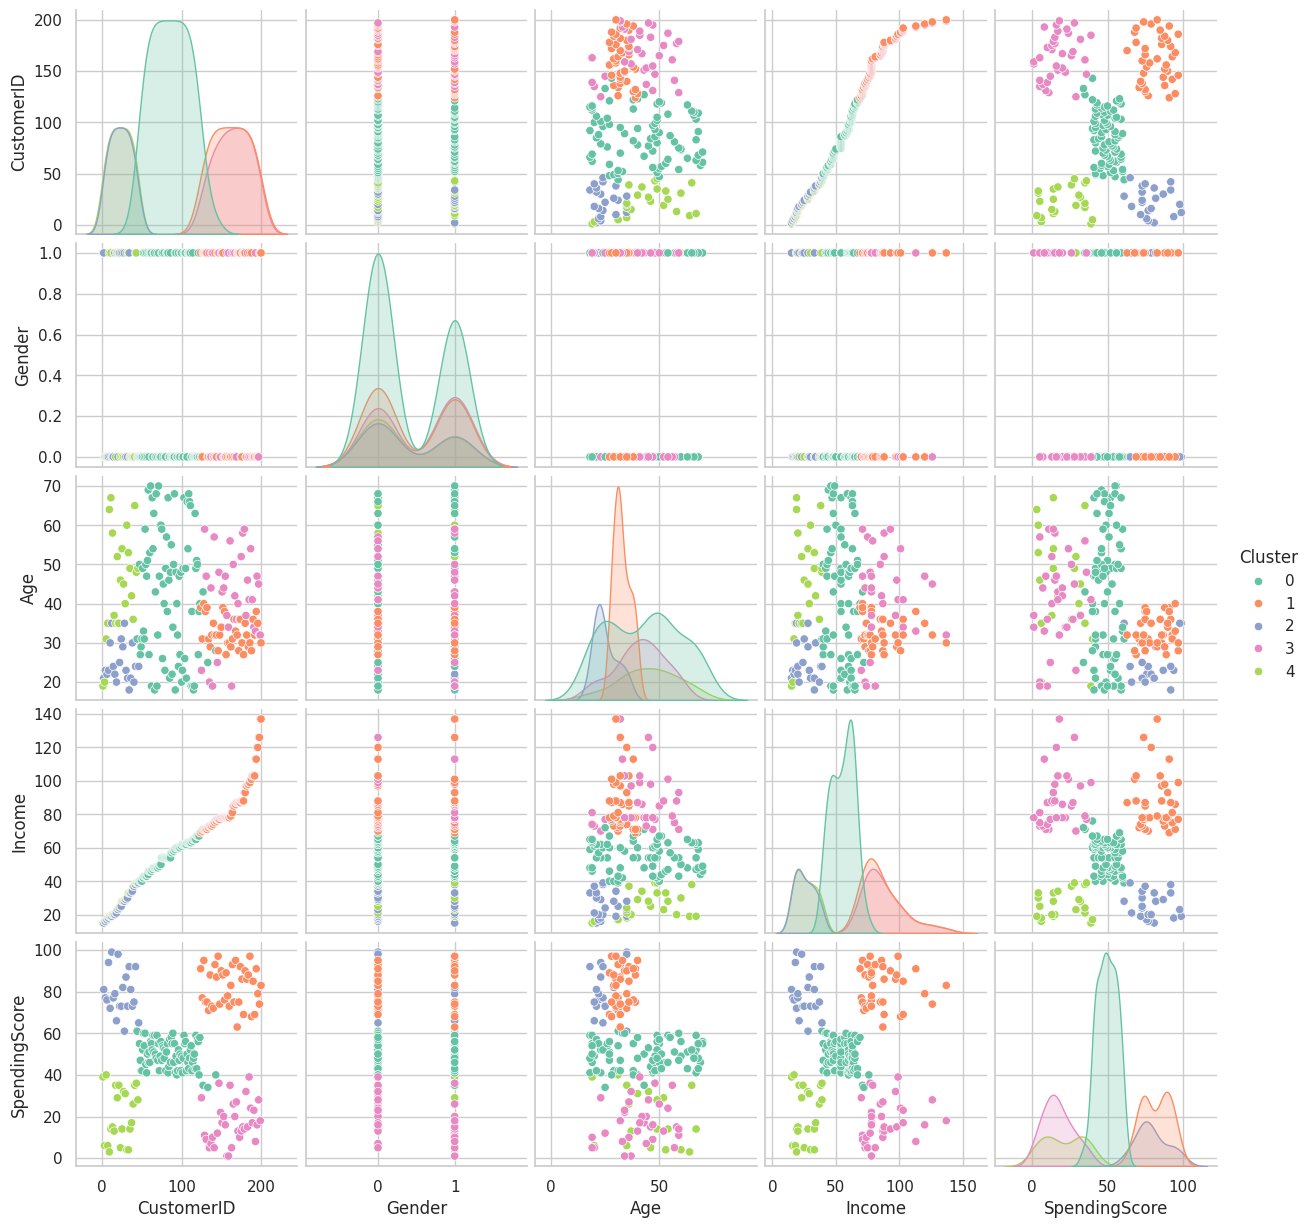

In [34]:
# ============================================================
# 33. PAIRPLOT WITH CLUSTERS
# ============================================================

sns.pairplot(
    df,
    hue='Cluster',
    palette='Set2'
)

plt.show()